In [1]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


# 1. Load dataset


In [2]:
from torchvision.datasets import CocoDetection
from torchvision import transforms
import torch

class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.dataset = CocoDetection(root=root, annFile=annFile)
        self.transforms = transforms
        self.class_names = [v['name'] for k, v in self.dataset.coco.cats.items() if v['id'] > 0]

        # Lọc chỉ những ảnh có ít nhất 1 box
        self.valid_idx = []
        for i in range(len(self.dataset)):
            _, anns = self.dataset[i]
            boxes = [ann for ann in anns if ann['category_id'] != 0]
            if len(boxes) > 0:
                self.valid_idx.append(i)

    def __getitem__(self, idx):
        idx = self.valid_idx[idx]  # chỉ lấy ảnh có box
        img, anns = self.dataset[idx]
        boxes = []
        labels = []
        for ann in anns:
            if ann['category_id'] == 0:
                continue
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])  # 🔹 Giữ nguyên COCO id

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.valid_idx)


# ---- 1. Load dataset ----
train = CocoDataset(
    root="/kaggle/input/acnedetv2/train",
    annFile="/kaggle/input/acnedetv2/train/_annotations.coco.json",
    transforms=transforms.ToTensor()
)

val = CocoDataset(
    root="/kaggle/input/acnedetv2/valid",
    annFile="/kaggle/input/acnedetv2/valid/_annotations.coco.json",
    transforms=transforms.ToTensor()
)

test = CocoDataset(
    root="/kaggle/input/acnedetv2/test",
    annFile="/kaggle/input/acnedetv2/test/_annotations.coco.json",
    transforms=transforms.ToTensor()
)

loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [3]:
img, target = train[0]

print("Ảnh:", type(img), img.shape)
print("Target keys:", target.keys())
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"])
print(target)

Ảnh: <class 'torch.Tensor'> torch.Size([3, 416, 416])
Target keys: dict_keys(['boxes', 'labels'])
Boxes shape: torch.Size([6, 4])
Labels: tensor([2, 1, 3, 3, 3, 1])
{'boxes': tensor([[135., 127., 161., 148.],
        [410., 128., 416., 148.],
        [396., 131., 414., 153.],
        [  6., 341.,  23., 359.],
        [ 10., 396.,  27., 416.],
        [294., 357., 309., 375.]]), 'labels': tensor([2, 1, 3, 3, 3, 1])}


## Các class

In [4]:
# --- Xem class names trong từng tập ---
print("Train classes:", train.class_names)
print("Val classes:", val.class_names)
print("Test classes:", test.class_names)

Train classes: ['comedone', 'nodules', 'papules', 'pustules']
Val classes: ['comedone', 'nodules', 'papules', 'pustules']
Test classes: ['comedone', 'nodules', 'papules', 'pustules']


## Data balance

In [5]:
from collections import Counter

def class_distribution(dataset):
    counts = Counter()
    for i in range(len(dataset)):
        _, target = dataset[i]
        labels = target["labels"].tolist()
        counts.update(labels)
    return {dataset.dataset.coco.cats[c]["name"]: n for c, n in counts.items()}

print("Train:", class_distribution(train))
print("Val:", class_distribution(val))
print("Test:", class_distribution(test))

Train: {'nodules': 2473, 'comedone': 15582, 'papules': 11875, 'pustules': 4550}
Val: {'comedone': 695, 'papules': 633, 'pustules': 354, 'nodules': 111}
Test: {'comedone': 99, 'nodules': 26, 'papules': 68, 'pustules': 32}


# 2. Visualize data

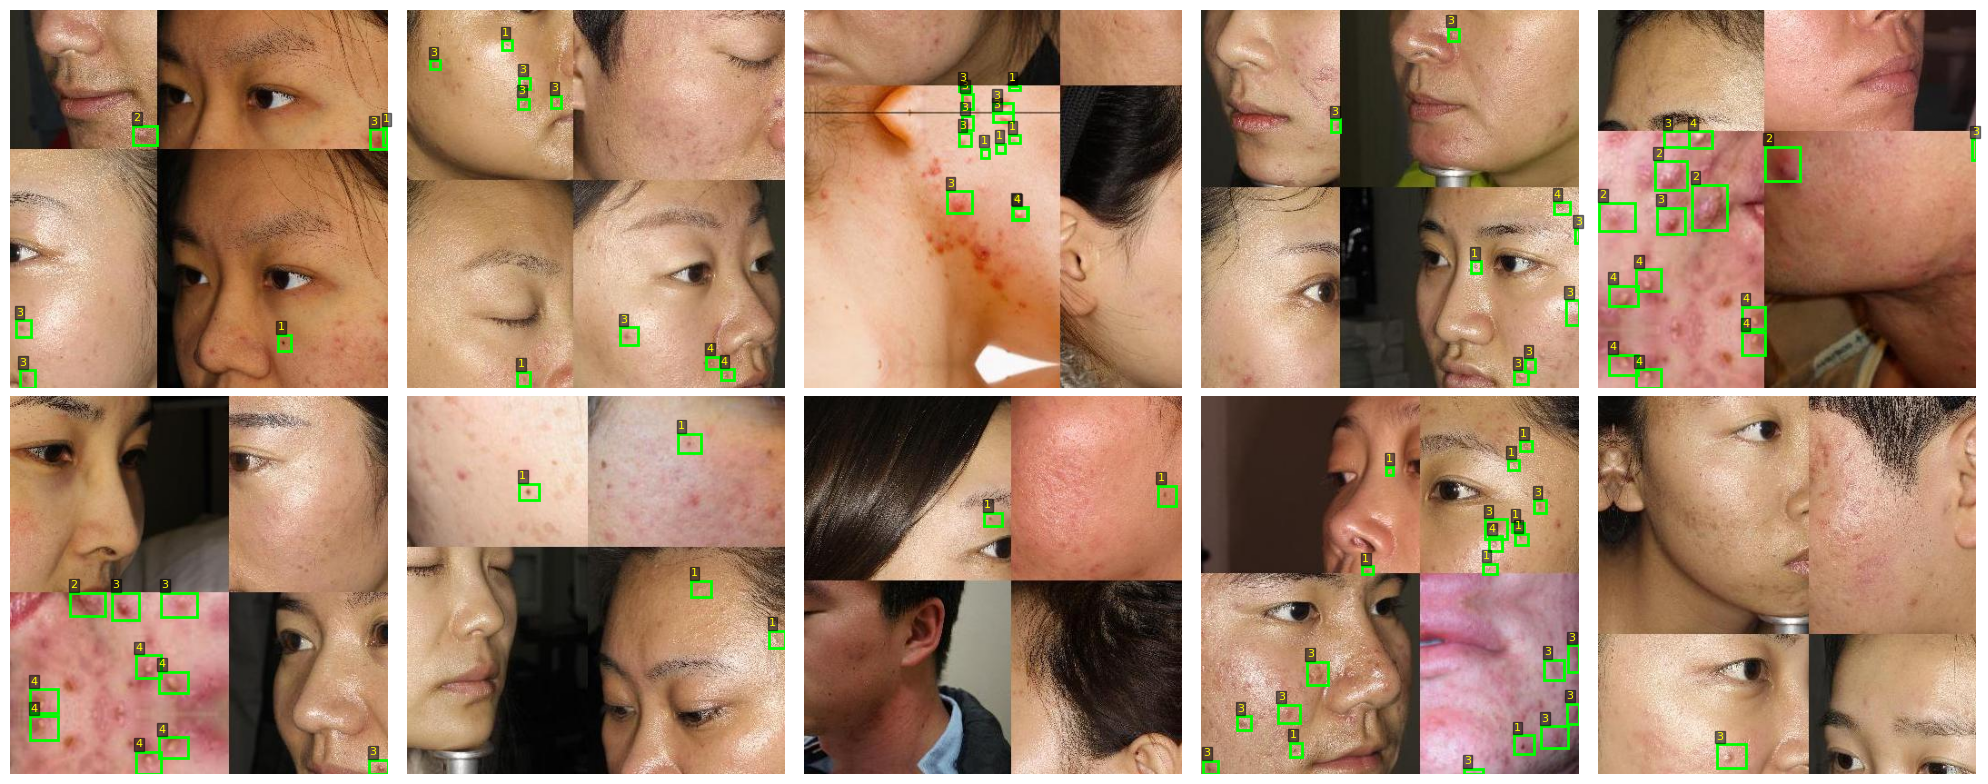

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- 2. Số lượng ảnh muốn hiển thị ----
num_images = 10
cols = 5
rows = (num_images + cols - 1) // cols

# ---- 3. Tạo figure ----
fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()

# ---- 4. Lặp qua các ảnh ----
for i in range(num_images):
    img, target = train[i]
    img = img.permute(1, 2, 0).numpy()

    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')

    # Vẽ bounding boxes
    boxes = target['boxes']
    labels = target['labels']
    for j, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

        # Nếu muốn hiển thị nhãn class id
        ax.text(
            x1, y1 - 5, str(labels[j].item()), color='yellow', fontsize=8,
            bbox=dict(facecolor='black', alpha=0.5, pad=1)
        )

# Ẩn các ô trống nếu num_images không chia hết cho cols
for j in range(num_images, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# 3. Tạo model

In [7]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# 1. Load DenseNet backbone
densenet = torchvision.models.densenet121(weights="DEFAULT")
backbone = densenet.features # bỏ phần classifier

# 2. Output channels = số channels cuối cùng của feature map
# Với DenseNet121, output là 1024
backbone.out_channels = 1024

# 3. Tạo anchor generator
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# 4. ROI Pooling
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

num_classes = len(train.class_names)
# 5. Tạo model Faster R-CNN
model = FasterRCNN(
    backbone,
    num_classes=num_classes+1,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 212MB/s]


In [8]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), 

# 4. DataLoader

In [9]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train, batch_size=3, shuffle=True, collate_fn=collate_fn
)

val_loader = DataLoader(
    val, batch_size=3, shuffle=False, collate_fn=collate_fn
)

test_loader = DataLoader(
    test, batch_size=3, shuffle=False, collate_fn=collate_fn
)

# 5. Training loop

In [10]:
!wandb login --relogin bdb6b35469181589a4f8b18159a4f3c1b7770eb8

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [11]:
import wandb
wandb.init(
    project="Densenet-detection",
    config={
        "epochs": 20,
        "batch_size": 3,
        "optimizer": "SGD",
        "lr": 0.005,
        "momentum": 0.9,
        "weight_decay": 0.001,
        "backbone": "DenseNet121",
        "model": "FasterRCNN"
    }
)
config = wandb.config

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [12]:
import torch

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=config.lr, momentum=config.momentum, weight_decay=config.weight_decay)

In [13]:
# ---- 3️⃣ Hàm tính confusion matrix ----
def compute_confusion_matrix(preds, targets, num_classes, iou_thresh=0.5):
    y_true, y_pred = [], []
    
    for pred, target in zip(preds, targets): # lặp qua mỗi ảnh
        boxes_pred = pred["boxes"]
        labels_pred = pred["labels"]
        boxes_true = target["boxes"]
        labels_true = target["labels"]

        matched_gt = set()
        
        # match predicted box với GT
        for i, bp in enumerate(boxes_pred):
            ious = box_iou(bp.unsqueeze(0), boxes_true)
            max_iou, idx = ious.max(1)
            idx = idx.item()
            max_iou = max_iou.item()
            
            if max_iou > iou_thresh and idx not in matched_gt:
                # TP
                y_pred.append(labels_pred[i].item())
                y_true.append(labels_true[idx].item())
                matched_gt.add(idx)
            else:
                # FP
                y_pred.append(labels_pred[i].item())
                y_true.append(0)  # label ngoài num_classes = background / FP
    
        # GT không được predict → FN
        for j, lt in enumerate(labels_true):
            if j not in matched_gt:
                y_true.append(lt.item())
                y_pred.append(0)  # predicted là background
    
    # Tạo confusion matrix với lớp background bổ sung
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes + 1)))
    return cm, y_true, y_pred

# ---- 4️⃣ Hàm IoU helper ----
def box_iou(box1, box2):
    # box: (x1, y1, x2, y2)
    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    inter_x1 = torch.max(box1[:, None, 0], box2[:, 0])
    inter_y1 = torch.max(box1[:, None, 1], box2[:, 1])
    inter_x2 = torch.min(box1[:, None, 2], box2[:, 2])
    inter_y2 = torch.min(box1[:, None, 3], box2[:, 3])
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    union = area1[:, None] + area2 - inter_area
    return inter_area / union

In [14]:
import torch
from tqdm import tqdm
import wandb
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import confusion_matrix
import numpy as np

# ---- 5️⃣ Vòng huấn luyện ----
num_epochs = config.epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, targets = batch
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        # 🧹 Dọn dẹp GPU memory
        del loss, loss_dict, images, targets
        torch.cuda.empty_cache()

    avg_train_loss = train_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, targets = batch
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Tạm bật train mode để model trả về loss_dict
            model.train()
            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())
            val_loss += loss.item()
            model.eval()

    avg_val_loss = val_loss / len(val_loader)

    # ---- 🔹 Log chỉ loss sau mỗi epoch ----
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss
    })

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")

# ---- 2️⃣ Sau khi train xong: tính Test Loss, mAP và Confusion Matrix ----
print("\n🚀 Training done! Now computing final test loss, mAP and confusion matrix...")

model.eval()
metric = MeanAveragePrecision()
all_preds, all_targets = [], []
test_loss = 0.0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating final performance"):
        images, targets = batch
    
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
        # --- Dự đoán ---
        outputs = model(images)

        # Lọc những predict có confidence > threshold
        CONF_THRESH = 0.4  # ngưỡng confidence tuỳ chỉnh, ví dụ 0.5 hoặc 0.6

        filtered_outputs = []
        for out in outputs:
            scores = out["scores"]
            keep = scores > CONF_THRESH  # mask các box có score đủ cao
            filtered_outputs.append({
                "boxes": out["boxes"][keep],
                "labels": out["labels"][keep],
                "scores": out["scores"][keep],
            })
        
        outputs = filtered_outputs
        
        # --- Tính test loss ---
        # ⚠️ FasterRCNN chỉ xuất loss khi ở train mode, nên bật tạm
        model.train()
        loss_dict = model(images, targets)
        batch_loss = sum(loss for loss in loss_dict.values()).item()
        test_loss += batch_loss
        model.eval()

        # --- Lưu prediction & target để tính mAP ---
        all_preds.extend([{k: v.cpu() for k, v in o.items()} for o in outputs])
        all_targets.extend([{k: v.cpu() for k, v in t.items()} for t in targets])

avg_test_loss = test_loss / len(test_loader)

def prepare_for_map(preds, targets):
    preds_new, targets_new = [], []
    for p, t in zip(preds, targets):
        p_new = p.copy()
        t_new = t.copy()
        # FasterRCNN labels: 1..N → TorchMetrics labels: 0..N-1
        p_new["labels"] = p["labels"] - 1
        t_new["labels"] = t["labels"] - 1
        preds_new.append(p_new)
        targets_new.append(t_new)
    return preds_new, targets_new


metric = MeanAveragePrecision(class_metrics=True)

preds_eval, targets_eval = prepare_for_map(all_preds, all_targets)
metric.update(preds_eval, targets_eval)
results = metric.compute()

# --- Compute confusion matrix ---
cm, y_true, y_pred = compute_confusion_matrix(all_preds, all_targets, num_classes)

# 🔹 Chuẩn hóa kiểu dữ liệu để W&B hiển thị đúng
y_true = [int(y) for y in y_true]
y_pred = [int(y) for y in y_pred]

# 🔹 Đảm bảo class_names khớp với số lớp
class_names = test.class_names
assert len(class_names) == num_classes, f"⚠️ class_names ({len(class_names)}) != num_classes ({num_classes})"

map_all = results["map"].item()        # mAP@[0.5:0.95]
map_50  = results["map_50"].item()     # mAP@0.5
map_75  = results["map_75"].item()     # mAP@0.75

print("\n📊 Final Evaluation Results:")
print(f"Test Loss : {avg_test_loss:.4f}")
print(f"mAP       : {map_all:.4f}")
print(f"mAP@0.5   : {map_50:.4f}")
print(f"mAP@0.75  : {map_75:.4f}\n")
print("mAP per class:", results["map_per_class"])


Epoch 1/20 [Val]: 100%|██████████| 98/98 [00:19<00:00,  5.04it/s]


[Epoch 1/20] Train Loss: 0.3671 | Val Loss: 0.2625


Epoch 2/20 [Val]: 100%|██████████| 98/98 [00:19<00:00,  5.00it/s]


[Epoch 2/20] Train Loss: 0.3461 | Val Loss: 0.2566


Epoch 3/20 [Val]: 100%|██████████| 98/98 [00:19<00:00,  5.03it/s]


...

[Epoch 19/20] Train Loss: 0.2007 | Val Loss: 0.1987


Epoch 20/20 [Val]: 100%|██████████| 98/98 [00:19<00:00,  5.01it/s]


[Epoch 20/20] Train Loss: 0.1986 | Val Loss: 0.1942

🚀 Training done! Now computing final test loss, mAP and confusion matrix...


Evaluating final performance: 100%|██████████| 15/15 [00:05<00:00,  2.55it/s]



📊 Final Evaluation Results:
Test Loss : 0.1874
mAP       : 0.2188
mAP@0.5   : 0.5208
mAP@0.75  : 0.1306

mAP per class: tensor([0.2412, 0.2026, 0.2536, 0.1779])


In [15]:
def prepare_for_map(preds, targets):
    preds_new, targets_new = [], []
    for p, t in zip(preds, targets):
        p_new = p.copy()
        t_new = t.copy()
        # FasterRCNN labels: 1..N → TorchMetrics labels: 0..N-1
        p_new["labels"] = p["labels"] - 1
        t_new["labels"] = t["labels"] - 1
        preds_new.append(p_new)
        targets_new.append(t_new)
    return preds_new, targets_new


metric = MeanAveragePrecision(class_metrics=True)

preds_eval, targets_eval = prepare_for_map(all_preds, all_targets)
metric.update(preds_eval, targets_eval)
results = metric.compute()

print("mAP:", results["map"])
print("mAP per class:", results["map_per_class"])
print("Classes:", results["classes"])

mAP: tensor(0.2188)
mAP per class: tensor([0.2412, 0.2026, 0.2536, 0.1779])
Classes: tensor([0, 1, 2, 3], dtype=torch.int32)


In [16]:
wandb.log({
    "Final Test Loss": avg_test_loss,
    "Final mAP": map_all,
    "Final mAP@0.5": map_50,
    "Final mAP@0.75": map_75,
})


In [17]:
import pandas as pd

ap_table = pd.DataFrame({
    "Class": class_names,
    "AP": results["map_per_class"].tolist()
})

wandb.log({"AP_table": wandb.Table(dataframe=ap_table)})

In [18]:
ap_table

,Class,AP
0,comedone,0.241182
1,nodules,0.202646
2,papules,0.253634
3,pustules,0.177935


In [19]:
from wandb.sklearn import plot_confusion_matrix

plot_confusion_matrix(
    y_true,
    y_pred,
    labels=["background", "comedones", "nodules", "papules", "pustules"]
)

🟩 Tổng cộng có 44 ảnh trong toàn bộ test set


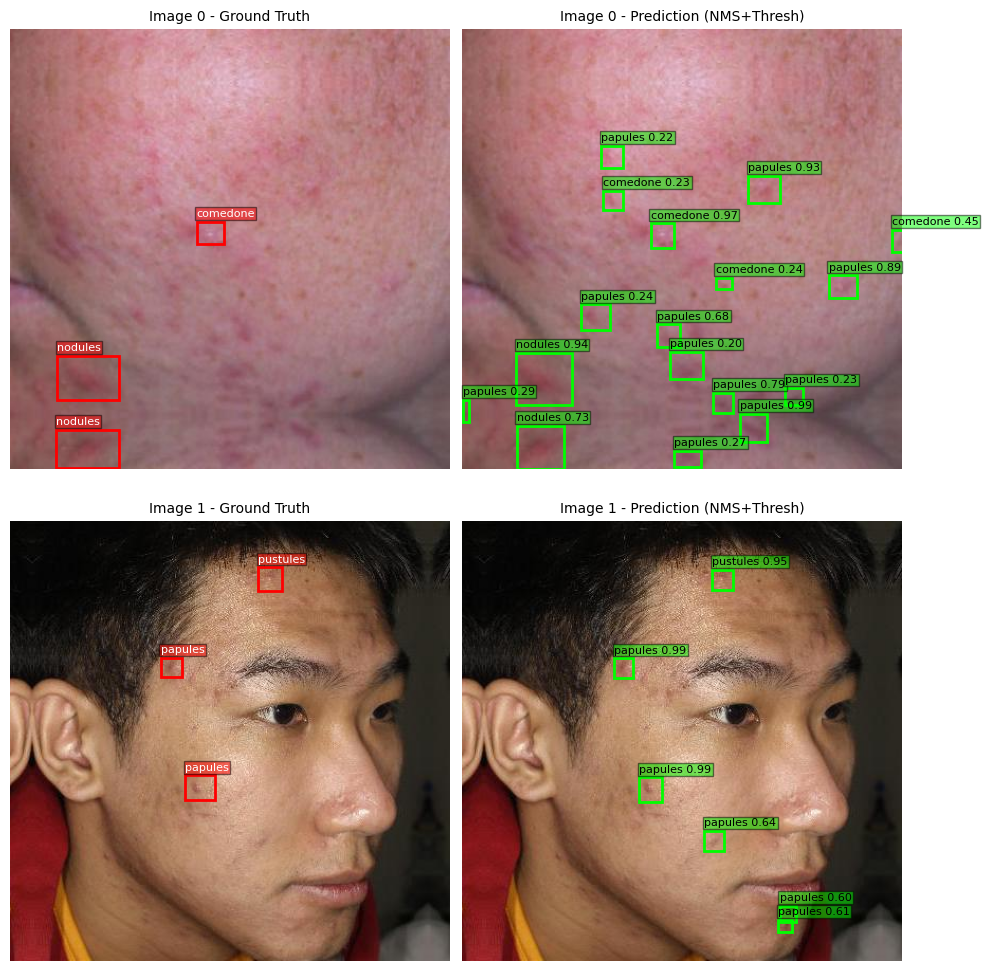

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import nms

def visualize_gt_pred_filtered(images, targets, outputs, class_names=None,
                               score_thresh=0.5, iou_thresh=0.5, n=4):
    """
    Hiển thị n ảnh theo cặp:
      - Bên trái: Ground Truth (màu đỏ)
      - Bên phải: Prediction (màu xanh) sau khi lọc theo score threshold và NMS.
    """
    from torchvision.ops import nms
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    n = min(n, len(images))
    fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))
    
    if n == 1:
        axes = [axes]
    
    for i in range(n):
        img_np = images[i].cpu().permute(1,2,0).numpy()
        
        # --- Ground Truth ---
        ax_left = axes[i][0] if n > 1 else axes[0]
        ax_left.imshow(img_np)
        ax_left.axis('off')
        ax_left.set_title(f"Image {i} - Ground Truth", fontsize=10)
        
        for box, label in zip(targets[i]['boxes'], targets[i]['labels']):
            x1, y1, x2, y2 = box.cpu()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax_left.add_patch(rect)
            # Hiển thị class name, trừ 1 để map 0-based list
            if class_names is not None:
                cls_idx = label.item() - 1
                if 0 <= cls_idx < len(class_names):
                    cls_name = class_names[cls_idx]
                else:
                    cls_name = str(label.item())
                ax_left.text(x1, y1-5, cls_name,
                             color='white', fontsize=8,
                             bbox=dict(facecolor='red', alpha=0.5, pad=1))
        
        # --- Prediction ---
        ax_right = axes[i][1] if n > 1 else axes[1]
        ax_right.imshow(img_np)
        ax_right.axis('off')
        ax_right.set_title(f"Image {i} - Prediction (NMS+Thresh)", fontsize=10)
        
        out = outputs[i]
        if len(out['boxes']) == 0:
            continue
        
        # --- Filter theo score threshold ---
        keep_score = out['scores'] > score_thresh
        boxes = out['boxes'][keep_score]
        scores = out['scores'][keep_score]
        labels = out['labels'][keep_score]
        
        # --- Áp dụng NMS ---
        if len(boxes) > 0:
            keep_nms = nms(boxes, scores, iou_threshold=iou_thresh)
            boxes = boxes[keep_nms]
            scores = scores[keep_nms]
            labels = labels[keep_nms]
        
        # --- Vẽ ---
        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.cpu()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax_right.add_patch(rect)
            if class_names is not None:
                cls_idx = label.item() - 1
                if 0 <= cls_idx < len(class_names):
                    cls_name = class_names[cls_idx]
                else:
                    cls_name = str(label.item())
                ax_right.text(x1, y1-5, f"{cls_name} {score:.2f}",
                              color='black', fontsize=8,
                              bbox=dict(facecolor='lime', alpha=0.5, pad=1))
            else:
                ax_right.text(x1, y1-5, f"{label.item()} {score:.2f}",
                              color='black', fontsize=8,
                              bbox=dict(facecolor='lime', alpha=0.5, pad=1))
    
    plt.tight_layout()
    plt.show()

filtered_imgs = []
filtered_targets = []
filtered_outputs = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        # ---- 1. Chuyển ảnh lên GPU ----
        images = [img.to(device) for img in images]

        # ---- 2. Model inference ----
        outputs = model(images)

        # ---- 3. Duyệt qua từng ảnh trong batch ----
        for img, tgt, out in zip(images, targets, outputs):
            filtered_imgs.append(img.cpu())  # chuyển về CPU để visualize
            filtered_targets.append(tgt)
            filtered_outputs.append(out)

print(f"🟩 Tổng cộng có {len(filtered_imgs)} ảnh trong toàn bộ test set")

# Visualize
visualize_gt_pred_filtered(
    filtered_imgs, 
    filtered_targets, 
    filtered_outputs, 
    class_names=test.class_names,
    score_thresh=0.2,
    iou_thresh=0.1,
    n=len(images)  # số ảnh trong batch
)


🟩 Tổng cộng có 35 ảnh chứa comedones trong toàn bộ test set


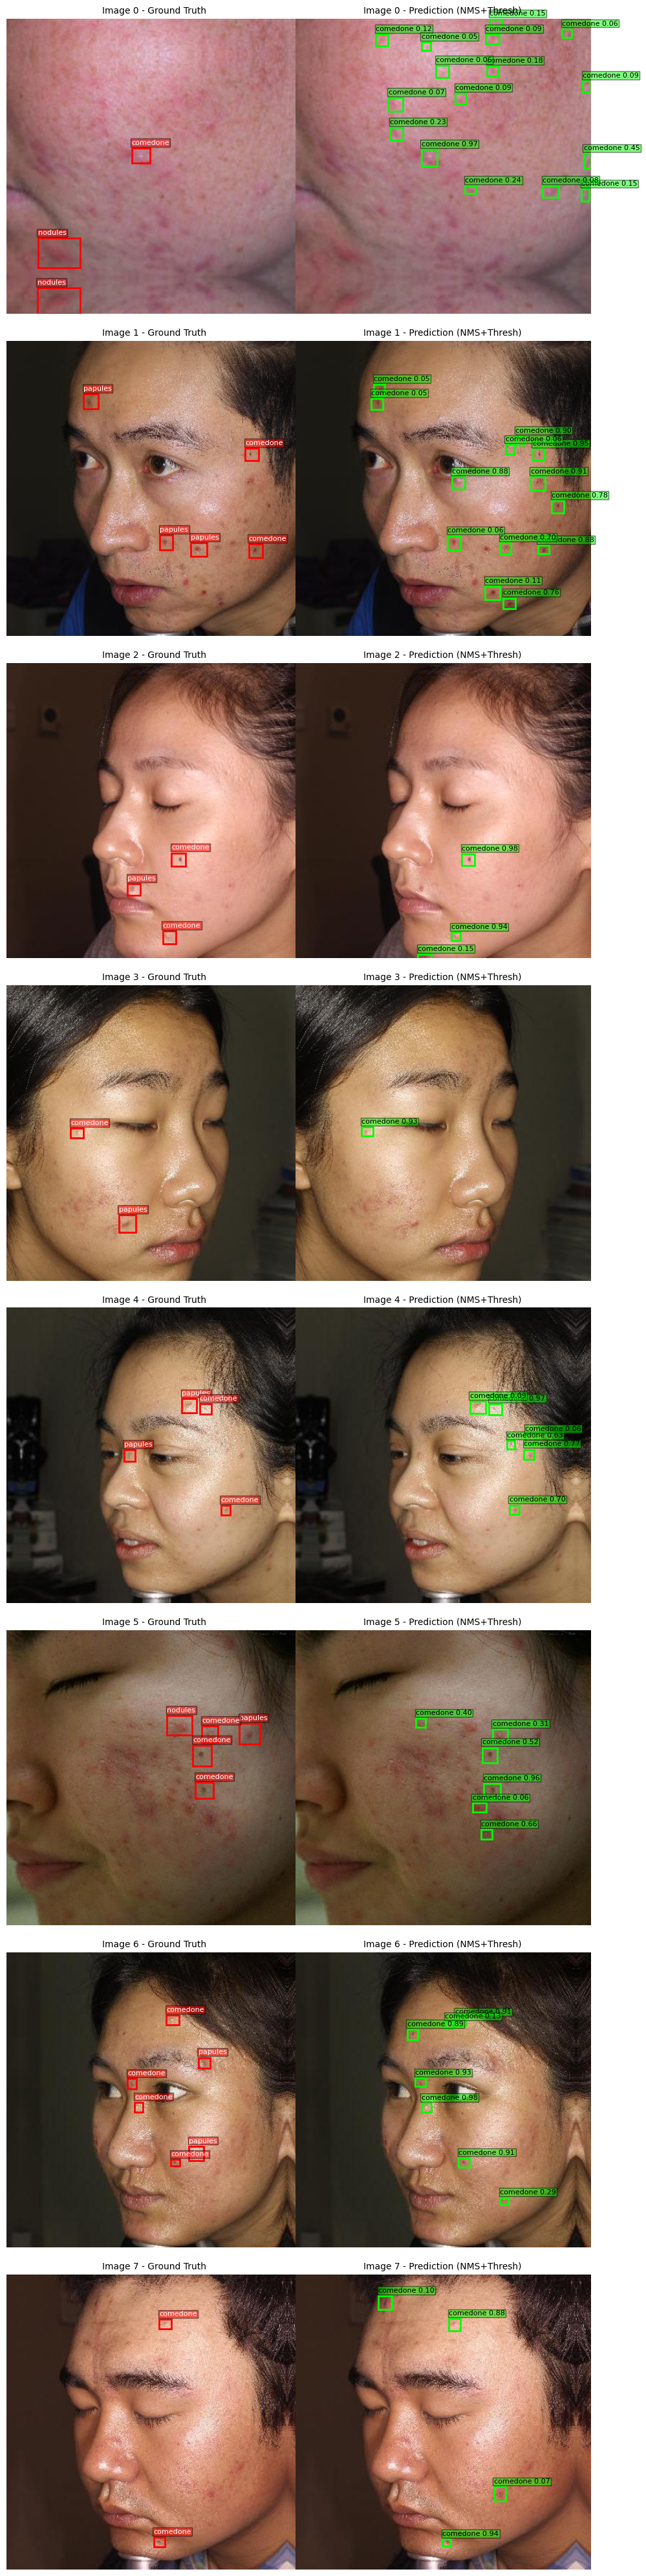

In [21]:
# ---- Filter chỉ những ảnh có comedones trong ground truth ----
comedones_id = 1

filtered_imgs = []
filtered_targets = []
filtered_outputs = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        # ---- 1. Chuyển ảnh lên GPU ----
        images = [img.to(device) for img in images]

        # ---- 2. Model inference ----
        outputs = model(images)

        # ---- 3. Duyệt qua từng ảnh trong batch ----
        for img, tgt, out in zip(images, targets, outputs):
            labels = tgt["labels"].cpu().numpy()

            if comedones_id in labels:
                # Chỉ giữ ảnh có comedones
                filtered_imgs.append(img.cpu())  # chuyển lại CPU để visualize sau
                filtered_targets.append(tgt)

                # Trong output, chỉ giữ box có label là comedones
                mask = out["labels"].cpu() == comedones_id
                filtered_out = {
                    "boxes": out["boxes"][mask],
                    "scores": out["scores"][mask],
                    "labels": out["labels"][mask],
                }
                filtered_outputs.append(filtered_out)

print(f"🟩 Tổng cộng có {len(filtered_imgs)} ảnh chứa comedones trong toàn bộ test set")

visualize_gt_pred_filtered(
    filtered_imgs,
    filtered_targets,
    filtered_outputs,
    class_names=test.class_names,
    score_thresh=0,
    iou_thresh=0,
    n=min(8, len(filtered_imgs))  # hiển thị tối đa 8 ảnh cho dễ xem
)

In [22]:
# ---- 💾 Lưu lại model sau khi train ----
model_save_path = "fasterrcnn_best.pth"
torch.save(model.state_dict(), model_save_path)
print(f"✅ Model saved successfully to: {model_save_path}")

✅ Model saved successfully to: fasterrcnn_best.pth
